In [14]:
from cil.io import TIFFStackReader
import numpy as np
import tifffile
import module_auxiliary as ma
import extended_data as ed
import matplotlib.pyplot as plt

In [ ]:
path = '/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_004_/compressed_XA_004_####.tiff'
stride = 1
A = range(1,6001,stride)
path_list = ma.generate_paths(path, A)
ny, nx = np.shape(tifffile.imread(path_list[0]))
data = np.empty((len(A), 10, nx))
for i in range(len(path_list)):
    if (i%1000)==0:
        print(i)
    data[i] = tifffile.imread(path_list[i])[:10,:]

0
1000
2000
3000
4000
5000


In [11]:
path_dark = '/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_004_/dark/dark.tiff'
path_obeam = '/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_004_/obeam/refHST6000.tiff'

dark = tifffile.imread(path_dark)[:10,:]
obeam = tifffile.imread(path_obeam)[:10,:]

data_normalized = -np.log((data - dark[np.newaxis,:,:])/(obeam[np.newaxis,:,:] - dark[np.newaxis,:,:]))

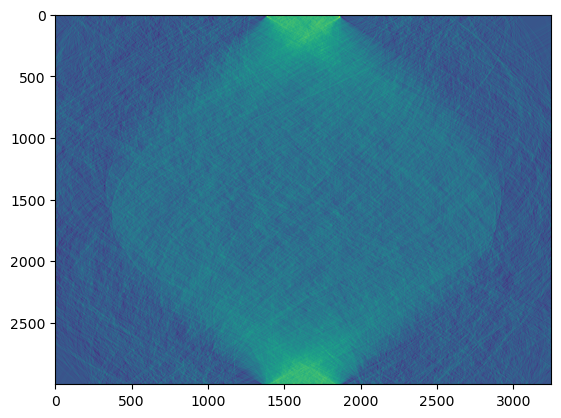

In [16]:
split_row = 3000
split_col = nx-248
raw_data_180 = ma.rearrange_3d_block_matrix(data_normalized, split_row, split_col)
plt.imshow(raw_data_180[:,0,:], aspect='auto')
plt.show()

In [18]:
from cil.framework import AcquisitionGeometry
stride = 1
angles = np.linspace(0, 180, 3000, endpoint=True, dtype=np.float32)
angles = angles[::stride]
N_pixels = np.shape(raw_data_180)[2]
N_slices = np.shape(raw_data_180)[1]
    
ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,N_pixels//2,0])\
                            .set_angles(angles)\
                            .set_panel((N_pixels,N_slices), pixel_size=(1,1))\
                            .set_labels(labels=('angle','vertical','horizontal'))


sinograms = ed.ExtendedData()
sinograms.set_data(data = raw_data_180)
sinograms.acquisition_data(geometry=ag)
sinograms.set_rotation_axis(position = [0,0,0], rotation = [0,0,1])

In [20]:
recon = sinograms.fbp()

In [35]:
import SimpleITK as sitk
full_path = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_stitch_total.tif'
full_recon = sitk.ReadImage(full_path)

In [44]:
import SimpleITK as sitk
full_path = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_reslice_itksnap.tif'
small_recon = sitk.ReadImage(full_path)
small_recon1 = sitk.GetArrayFromImage(small_recon)

TIFFReadDirectory: Warning, Unknown field with tag 50838 (0xc696) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50839 (0xc697) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50838 (0xc696) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50839 (0xc697) encountered.


In [ ]:
full_recon1 = sitk.GetArrayFromImage(full_recon)

(3985, 3020, 670)


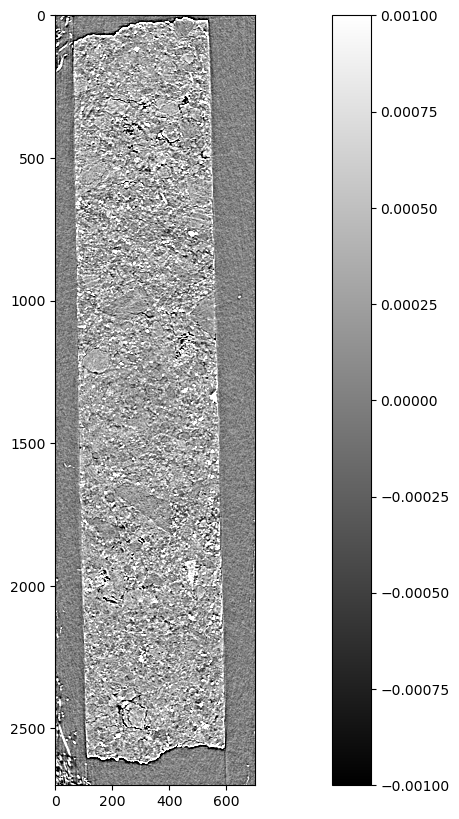

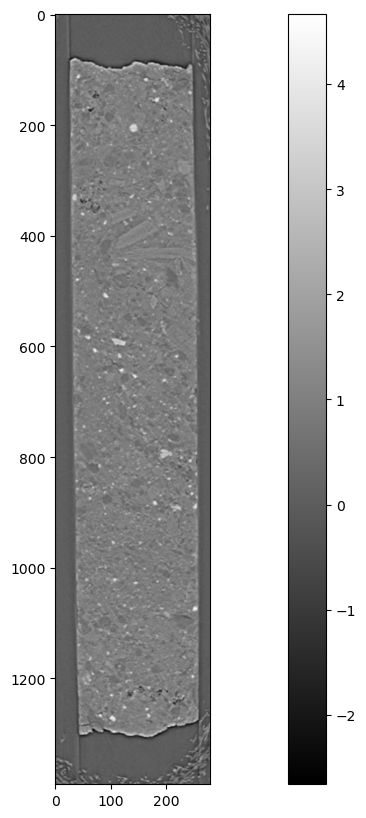

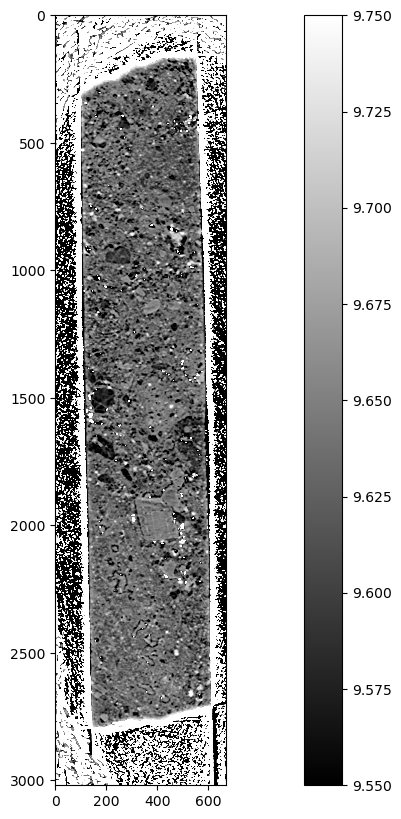

In [77]:
plt.figure(figsize=(20,10))
plt.imshow(recon.as_array()[0,300:3000,1300:2000], cmap='gray')
plt.clim([-0.001,0.001])
plt.colorbar()
plt.show()
plt.figure(figsize=(20,10))
plt.imshow(small_recon1[600,:,:], cmap='gray')
plt.colorbar()
plt.show()
plt.figure(figsize=(20,10))
plt.imshow(np.log(full_recon1[1800,:,:]), cmap='gray')
plt.clim([9.55,9.75])
plt.colorbar()
plt.show()

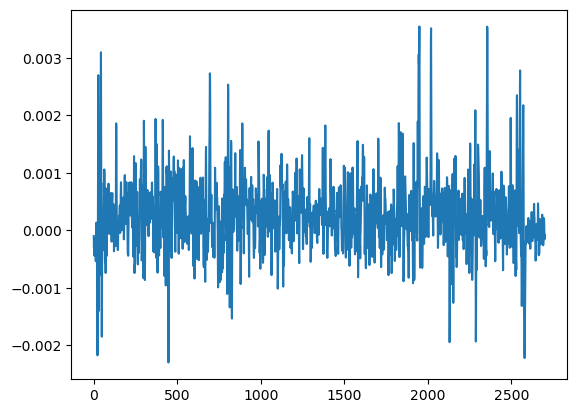

In [52]:
plt.plot(recon.as_array()[0,300:3000,1700])

15082


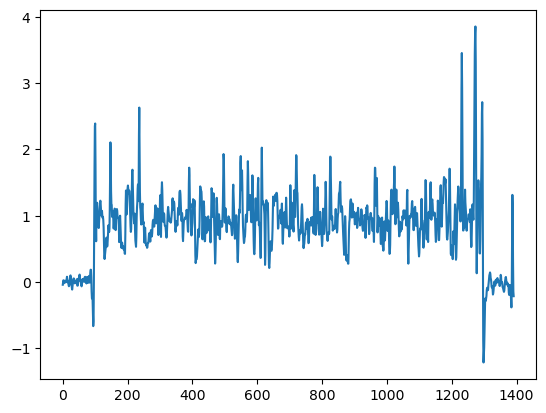

In [64]:
plt.plot(small_recon1[600,:,100])
print(full_recon1[600,2000,100])

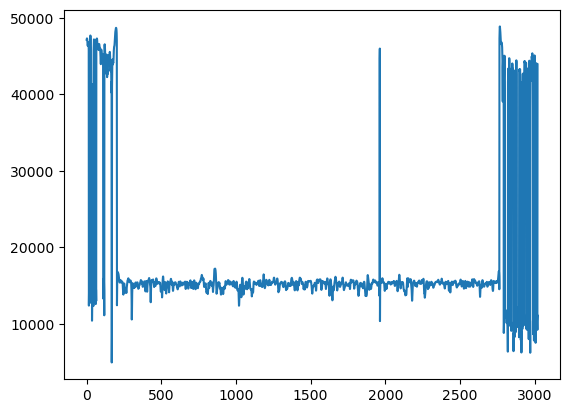

In [55]:
plt.plot(full_recon1[1800,:,300])